# Clustering No Jerarquico - K-means

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

In [9]:
## Cargamos los datos

data = pd.read_csv(r"Mall_Customers.csv")

data.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [10]:
# Definimos que variable usar

X = data[["Annual Income (k$)", "Spending Score (1-100)"]]

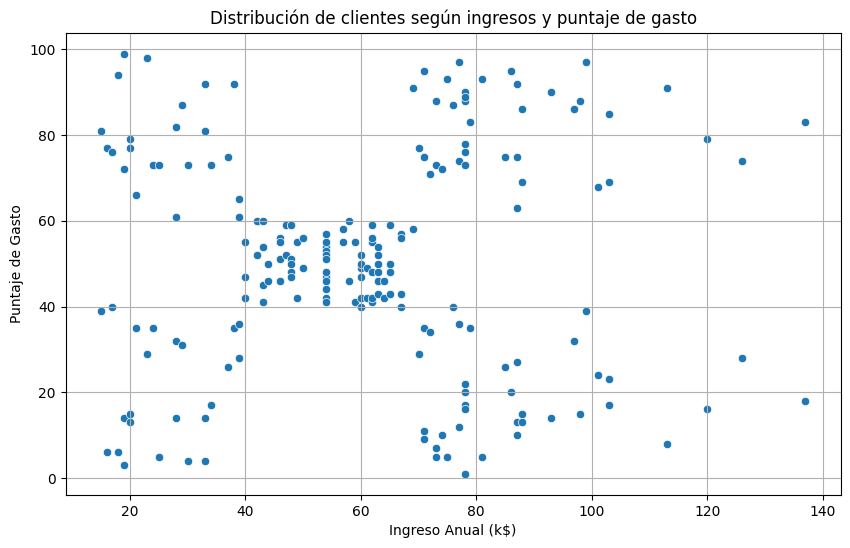

In [11]:
# Visualizar con scatter plot
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x =data["Annual Income (k$)"],
    y =data["Spending Score (1-100)"]
)

plt.title("Distribución de clientes según ingresos y puntaje de gasto")
plt.xlabel("Ingreso Anual (k$)")
plt.ylabel("Puntaje de Gasto")   
plt.grid(True)   
plt.show() 

In [12]:
# Normalizar las variables

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

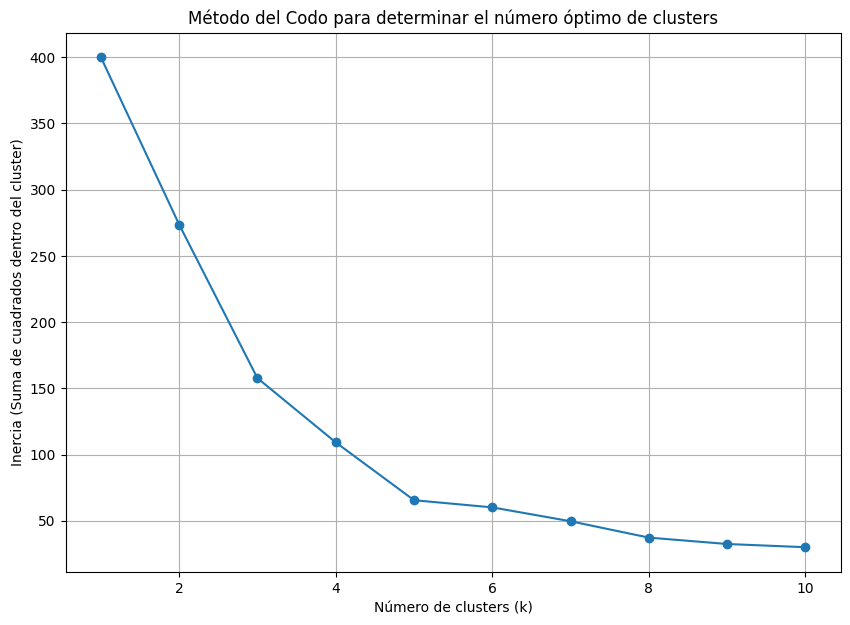

In [13]:
# Método del codo para determinar el número óptimo de clusters

inertia = []
K_range = range(1, 11)

for k in K_range:
    kmean = KMeans(n_clusters=k, random_state=42)
    kmean.fit(X_scaled)
    inertia.append(kmean.inertia_)
    
# Visualización del método del codo

plt.figure(figsize=(10, 7))
plt.plot(K_range, inertia, marker='o')
plt.title("Método del Codo para determinar el número óptimo de clusters")
plt.xlabel("Número de clusters (k)")
plt.ylabel("Inercia (Suma de cuadrados dentro del cluster)")
plt.grid()
plt.show()


Centroides de cada cluster (en el espacio normalizado):
[[-0.20091257 -0.02645617]
 [ 0.99158305  1.23950275]
 [-1.32954532  1.13217788]
 [ 1.05500302 -1.28443907]
 [-1.30751869 -1.13696536]]

Silhouette Score: 0.5547


<Axes: xlabel='Annual Income (k$)', ylabel='Spending Score (1-100)'>

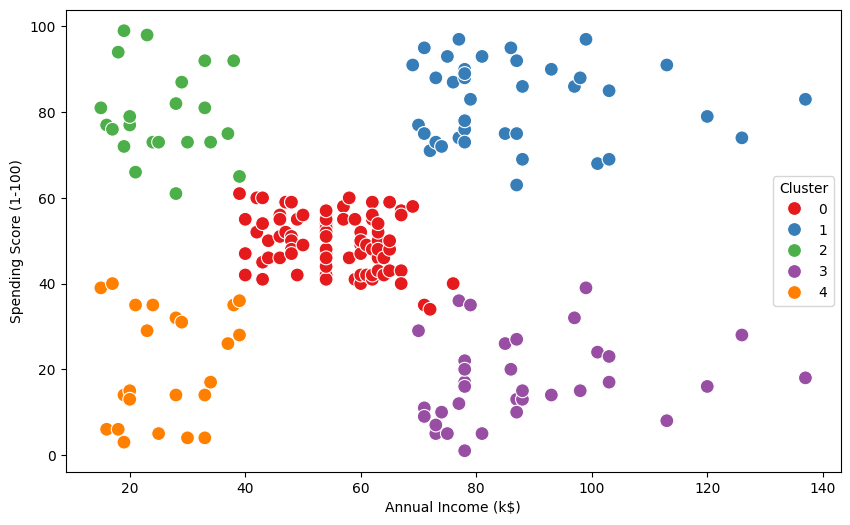

In [14]:
# Entrenamiento del modelo final

kmeans = KMeans(n_clusters=5, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

# Añadimos el cluster al dataframe original
data['Cluster'] = clusters

# Ver centroides de cada cluster
print("\nCentroides de cada cluster (en el espacio normalizado):")
print(kmeans.cluster_centers_)

# Scoring de solhoutte

score = silhouette_score(X_scaled, clusters)
print(f"\nSilhouette Score: {score:.4f}")


# Visualización del scatter plot con los clusters
plt.figure(figsize=(10, 6))
sns.scatterplot(
    y=data["Spending Score (1-100)"],
    x=data["Annual Income (k$)"],
    hue=data["Cluster"],
    palette="Set1",
    s=100
)

- Silhouette Score: 0.5547 esta entre 0-1

- Valores por encima de 0.5 los clusters estan bastantes claros, pero entre 0.25 y 05 esta bien, pero no es lo ideal. Por debajo de 0.25 no vale para nada. 